<a href="https://colab.research.google.com/github/KonungurProFer/Proyecto_telecom_X/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Extracción

## 1. Carga de Datos y Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json")
print(f"   Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

   Dimensiones: 7267 filas x 6 columnas


## 1.2 Conociendo los datos

###  Diccionario de Datos - TelecomX LATAM

## Descripción General

Este diccionario contiene la información detallada de todas las variables presentes en el dataset de TelecomX.

---

##  Variables del Dataset

### 1 Identificación del Cliente

- **`customerID`**: número de identificación único de cada cliente


### 2 Cancelación del Servicio

- **`Churn`**: si el cliente dejó o no la empresa
  - `Yes` o `No`


### 3 Información del Cliente (`customer`)

- **`gender`**: género (masculino y femenino)
  - `Male` o `Female`

- **`SeniorCitizen`**: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
  - `0` = No
  - `1` = Sí

- **`Partner`**: si el cliente tiene o no una pareja
  - `Yes` o `No`

- **`Dependents`**: si el cliente tiene o no dependientes
  - `Yes` o `No`

- **`tenure`**: meses de contrato del cliente
  - Valor numérico en meses


### 4 Servicios de Telefonía (`phone`)

- **`PhoneService`**: suscripción al servicio telefónico
  - `Yes` o `No`

- **`MultipleLines`**: suscripción a más de una línea telefónica
  - `Yes`, `No` o `No phone service`


### 5 Servicios de Internet (`internet`)

- **`InternetService`**: suscripción a un proveedor de internet
  - `DSL`, `Fiber optic`, `No`

- **Servicios adicionales**:
  - **`OnlineSecurity`**: suscripción adicional de seguridad en línea
  - **`OnlineBackup`**: suscripción adicional de respaldo en línea
  - **`DeviceProtection`**: suscripción adicional de protección del dispositivo
  - **`TechSupport`**: suscripción adicional de soporte técnico, menor tiempo de espera
  - **`StreamingTV`**: suscripción de televisión por cable
  - **`StreamingMovies`**: suscripción de streaming de películas


### 6 Información de la Cuenta (`account`)

- **`Contract`**: tipo de contrato
  - `Month-to-month`, `One year`, `Two year`

- **`PaperlessBilling`**: si el cliente prefiere recibir la factura en línea
  - `Yes` o `No`

- **`PaymentMethod`**: forma de pago
  - `Bank transfer`, `Credit card`, `Electronic check`, `Mailed check`

- **`Charges.Monthly`**: total de todos los servicios del cliente por mes
  - Valor numérico

- **`Charges.Total`**: total gastado por el cliente
  - Valor numérico

---

##  Notas Importantes

- Las variables categóricas utilizan principalmente valores binarios (`Yes`/`No`) o categorías específicas
- Los valores numéricos incluyen `tenure`, `Charges.Monthly` y `Charges.Total`
- `SeniorCitizen` es la única variable que usa codificación numérica binaria (0/1) en lugar de texto
- Algunas variables de servicios pueden tener el valor `No internet service` o `No phone service` cuando el cliente no tiene el servicio base correspondiente.

## 1.3 Vista Inicial de los Datos

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# 🔧 Transformación

## 2. Desanidado de Datos JSON

In [ ]:
#Normalizando
df_customer=pd.json_normalize(df["customer"])
df_phone=pd.json_normalize(df["phone"])
df_internet=pd.json_normalize(df["internet"])
df_account=pd.json_normalize(df["account"])

# Concatenar todos los dataframes normalizados
df_normalizado= pd.concat([df[["customerID","Churn"]], df_customer, df_phone, df_internet, df_account], axis=1)
pd.set_option('display.max_columns', None)
df_normalizado.head()
print(f"   Dimensiones finales: {df_normalizado.shape[0]} filas x {df_normalizado.shape[1]} columnas")

   Dimensiones finales: 7267 filas x 21 columnas


## 2.2 Exploración del Dataset Normalizado

In [ ]:
# Información detallada
df_normalizado.info()

#Verificando que valores tenemos
for col in df_normalizado.columns:
    print(df_normalizado[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## 2.3 Verificación de Nulos

In [ ]:
#Verificando que no exista nulos
df_normalizado.isna().sum().rename("Nulos")

,Nulos
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


## 2.4 Verificación de Duplicados

In [ ]:
datos_duplicados = df_normalizado.duplicated().sum()
print(f"Registros duplicados: {datos_duplicados}")

Registros duplicados: 0


### Detección de problemas

In [ ]:
df_normalizado["Churn"].unique()
df_normalizado=df_normalizado.query('Churn!=""')

In [ ]:
# Buscar valores no numéricos en Charges.Total
df_normalizado[~df_normalizado['Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')].head()
df_normalizado=df_normalizado[df_normalizado['Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')]

In [ ]:
#Creando la columna cuentas diarias
df_normalizado["Cuentas_diarias"]=(df_normalizado['Charges.Monthly']/30).round(3)

In [ ]:
columnas_tf= ["Churn",
              "Partner",
              "Dependents",
              "PaperlessBilling",
              "OnlineSecurity",
              "OnlineBackup",
              "DeviceProtection",
              "TechSupport",
              "StreamingTV",
              "StreamingMovies",
              "PhoneService",
              "MultipleLines"]

#Ajustando datos
ajustando_tf= df_normalizado[columnas_tf]
for var in ajustando_tf.columns:
  df_normalizado[var]=df_normalizado[var].apply(lambda x: x.replace("No internet service", "0").replace("No phone service", "0").replace("No", "0").replace("Yes", "1"))

df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.187
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.997
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.267
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.797


## 2.5 Conversión de Tipo de Datos

In [ ]:
df_normalizado[columnas_tf]=df_normalizado[columnas_tf].astype(np.int64)
df_normalizado['Charges.Total']=df_normalizado["Charges.Total"].astype(np.float64)
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   int64  
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16  Contract          7032 non-null   object 
 17  

## 2.6 Reorganizando

In [ ]:
name_columns= {"customerID": "ID",
               "Churn": "Abandonó_Servicio",
               "gender": "Género",
               "SeniorCitizen": "Cliente_Señor",
               "Partner": "Tiene_Pareja",
               "Dependents": "Tiene_Dependientes",
               "tenure": "Antigüedad",
               "PhoneService": "Servicio_Telefónico",
               "MultipleLines": "Múltiples_Líneas",
               "InternetService": "Servicio_Internet",
               "OnlineSecurity": "Seguridad_Online",
               "OnlineBackup": "Respaldo_Online",
               "DeviceProtection": "Protección_Dispositivo",
               "TechSupport": "Soporte_Técnico",
               "StreamingTV": "TV_Streaming",
               "StreamingMovies": "Películas_Streaming",
               "Contract": "Tipo_Contrato",
               "PaperlessBilling": "Facturación_Sin_Papel",
               "PaymentMethod": "Método_Pago",
               "Charges.Monthly": "Cargo_Mensual",
               "Charges.Total": "Cargo_Total",
               "Cuentas_diarias": "Cargo_Diario"}
df_normalizado=df_normalizado.rename(columns=name_columns)

name_values={
    "Female":"Femenino",
    "Male":"Masculino",
    "Fiber optic":"Fibra optica",
    "One year":"Anual",
    "Month-to-month":"Mensual",
    "Two year":"Bienal",
    "Mailed check": "Cheque enviado por correo",
    "Electronic check": "Cheque electrónico",
    "Credit card (automatic)": "Tarjeta de crédito (automático)",
    "Bank transfer (automatic)": "Transferencia bancaria (automática)"
}
df_normalizado.replace(name_values, inplace=True)

#Reseteando índice
df_normalizado.reset_index(drop=True, inplace=True)

df_normalizado.sample(6)

,ID,Abandonó_Servicio,Género,Cliente_Señor,Tiene_Pareja,Tiene_Dependientes,Antigüedad,Servicio_Telefónico,Múltiples_Líneas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Protección_Dispositivo,Soporte_Técnico,TV_Streaming,Películas_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
265,0396-HUJBP,0,Femenino,0,0,0,2,1,0,No,0,0,0,0,0,0,Mensual,0,Cheque enviado por correo,19.30,44.40,0.643
6564,9350-ZXYJC,0,Femenino,0,0,0,4,1,1,No,0,0,0,0,0,0,Bienal,1,Tarjeta de crédito (automático),25.30,116.95,0.843
4642,6563-VRERX,0,Masculino,0,1,1,33,1,0,No,0,0,0,0,0,0,Anual,0,Cheque enviado por correo,20.60,690.25,0.687
2390,3424-NMNBO,1,Masculino,1,1,0,58,1,1,Fibra optica,1,1,1,0,1,1,Anual,1,Cheque electrónico,108.85,6287.25,3.628
5942,8393-JMVMB,0,Masculino,0,0,0,1,1,0,No,0,0,0,0,0,0,Mensual,0,Cheque enviado por correo,19.45,19.45,0.648
5868,8263-QMNTJ,0,Masculino,0,1,0,72,1,1,Fibra optica,1,1,1,1,1,1,Bienal,1,Cheque electrónico,115.55,8425.30,3.852


# Carga y análisis

## 3 **Análisis descriptivo**<br>
Con el método describe, podemos ver las estadísticas descriptivas de nuestro DF. El análisis descriptivo ayuda con la comprensión de la distribución y el comportamiento de los clientes de Telecom X.

Se hará foco en la media (mean), mediana(50% o segundo cuartil) y desviación estándar(std).

In [ ]:
df_describe=df_normalizado.describe().T
estilo_descripcion = df_describe.style
estilo_descripcion.format({"count": "{:.0f}",
                           "mean": "{:.2%}",
                           "std": "{:.2%}",
                           "25%": "{:.2%}",
                           "50%": "{:.2%}",
                           "75%": "{:.2%}",
                           "max": "{:.2f}",
                           "min": "{:.2f}"
                        })

,count,mean,std,min,25%,50%,75%,max
Abandonó_Servicio,7032,26.58%,44.18%,0.00,0.00%,0.00%,100.00%,1.00
Cliente_Señor,7032,16.24%,36.88%,0.00,0.00%,0.00%,0.00%,1.00
Tiene_Pareja,7032,48.25%,49.97%,0.00,0.00%,0.00%,100.00%,1.00
Tiene_Dependientes,7032,29.85%,45.76%,0.00,0.00%,0.00%,100.00%,1.00
Antigüedad,7032,3242.18%,2454.53%,1.00,900.00%,2900.00%,5500.00%,72.00
Servicio_Telefónico,7032,90.33%,29.56%,0.00,100.00%,100.00%,100.00%,1.00
Múltiples_Líneas,7032,42.19%,49.39%,0.00,0.00%,0.00%,100.00%,1.00
Seguridad_Online,7032,28.65%,45.22%,0.00,0.00%,0.00%,100.00%,1.00
Respaldo_Online,7032,34.49%,47.54%,0.00,0.00%,0.00%,100.00%,1.00
Protección_Dispositivo,7032,34.39%,47.50%,0.00,0.00%,0.00%,100.00%,1.00


In [ ]:
import seaborn as sns
colores = ['#4CAF50', '#F44336'] # Verde para No Abandono, Rojo para Sí Abandono

def grafica_evasion():
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x='Abandonó_Servicio', y='Cargo_Mensual', data=df_normalizado, hue='Abandonó_Servicio', palette=colores, ax=ax, legend=False)
    ax.set_title('Distribución de Cargo Mensual por Abandono de Servicio', fontsize=16, fontweight='bold')
    ax.set_xlabel('Abandonó Servicio (0=No, 1=Sí)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cargo Mensual', fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1]) # Establecer ticks explícitamente
    ax.set_xticklabels(['No Abandonó', 'Sí Abandonó'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    fig.savefig("grafico_cargomensual_boxplot.jpg", transparent=True)
    plt.show()
    return plt

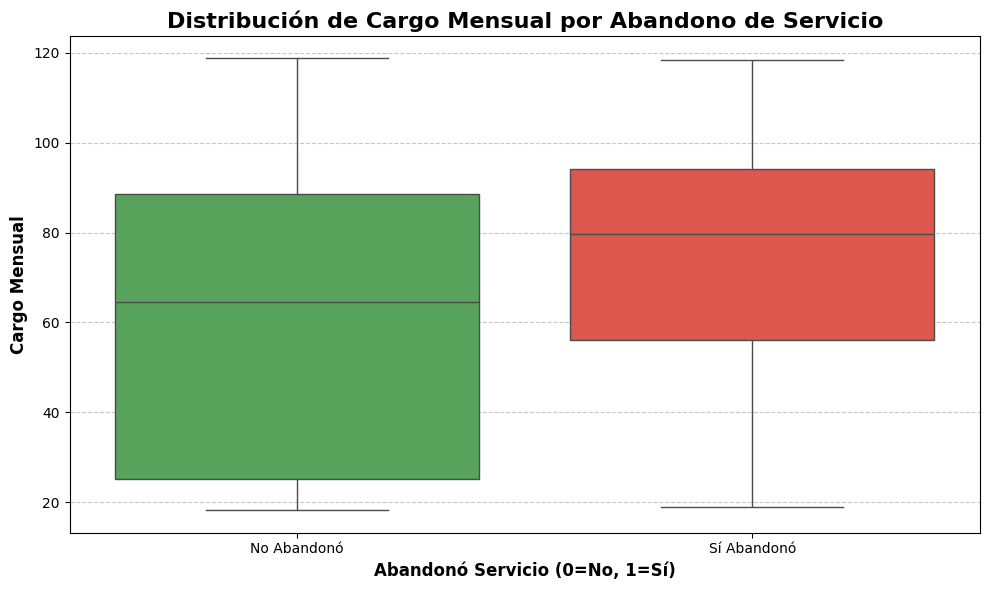

In [36]:
grafica_evasion().show()

###  Observaciones
---
* **Tasa de Evasión actual:** `26.58%`
* **Conclusión:** Se observa que 1 de cada 4 clientes decide abandonar el servicio.
* **Recomendación Estratégica: Dado que la tasa de abandono supera el 20%, es urgente revisar las estrategias de retención y analizar los motivos de salida en el segmento "Si" para frenar la pérdida.**


##3.3 Recuento de evasión por variables categóricas

In [ ]:
#Variables categóricas
variables_categoricas = ["Género", "Tipo_Contrato", "Método_Pago", "Servicio_Internet", "Facturación_Sin_Papel", "Tiene_Pareja", "Tiene_Dependientes", "Cliente_Señor"]
extension=len(variables_categoricas)

In [ ]:
cut_df=pd.cut(df_normalizado['Antigüedad'], bins=[0,18,36,54,72])
import seaborn as sns

In [ ]:
def grafica_evasion_categorica():
    #Creando los subplots
  fig, axs = plt.subplots(4,2, figsize=(14,22))
  fig.subplots_adjust(hspace=1, wspace= 0.6, top=0.92)
  axs_planos = axs.ravel()

  for idx, v in enumerate(variables_categoricas):
      # Creando tabla de porcentajes para el churn
      churn_counts = df_normalizado.groupby(v)['Abandonó_Servicio'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

      # Graficando el pie chart
      labels = ['No Abandonó', 'Sí Abandonó']
      sizes = churn_counts.iloc[:, [0, 1]].mean()

      # Para cada categoría, crearemos un pie chart
      ax = axs_planos[idx]
      wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90, textprops={'color':'black', 'fontweight':'bold'})
      ax.set_title(f'Distribución de Churn por {v}', fontsize=12, fontweight='bold')
      ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

      # Ajustar el color de los porcentajes para que sean visibles
      for autotext in autotexts:
          autotext.set_color('white')

  # Ajustes finales, si los hay, aunque con pie charts no suelen necesitarse leyendas globales
  # ya que cada pie chart tiene sus etiquetas y porcentajes
  # Remover leyendas duplicadas si es necesario
  for ax in axs_planos:
      if ax.has_data(): # Comprobar si el eje tiene datos (evitar ejes vacíos)
          ax.legend().set_visible(False) # Ocultar leyendas individuales si el pie ya es auto-explicativo
      ax.set_ylabel('') # Eliminar etiquetas de Y para pie charts
      ax.set_xlabel('') # Eliminar etiquetas de X para pie charts


  plt.tight_layout()
  fig.savefig("grafico_pie_categoricas.jpg", transparent=True) # Cambiar nombre del archivo para reflejar el nuevo tipo de gráfico
  return plt

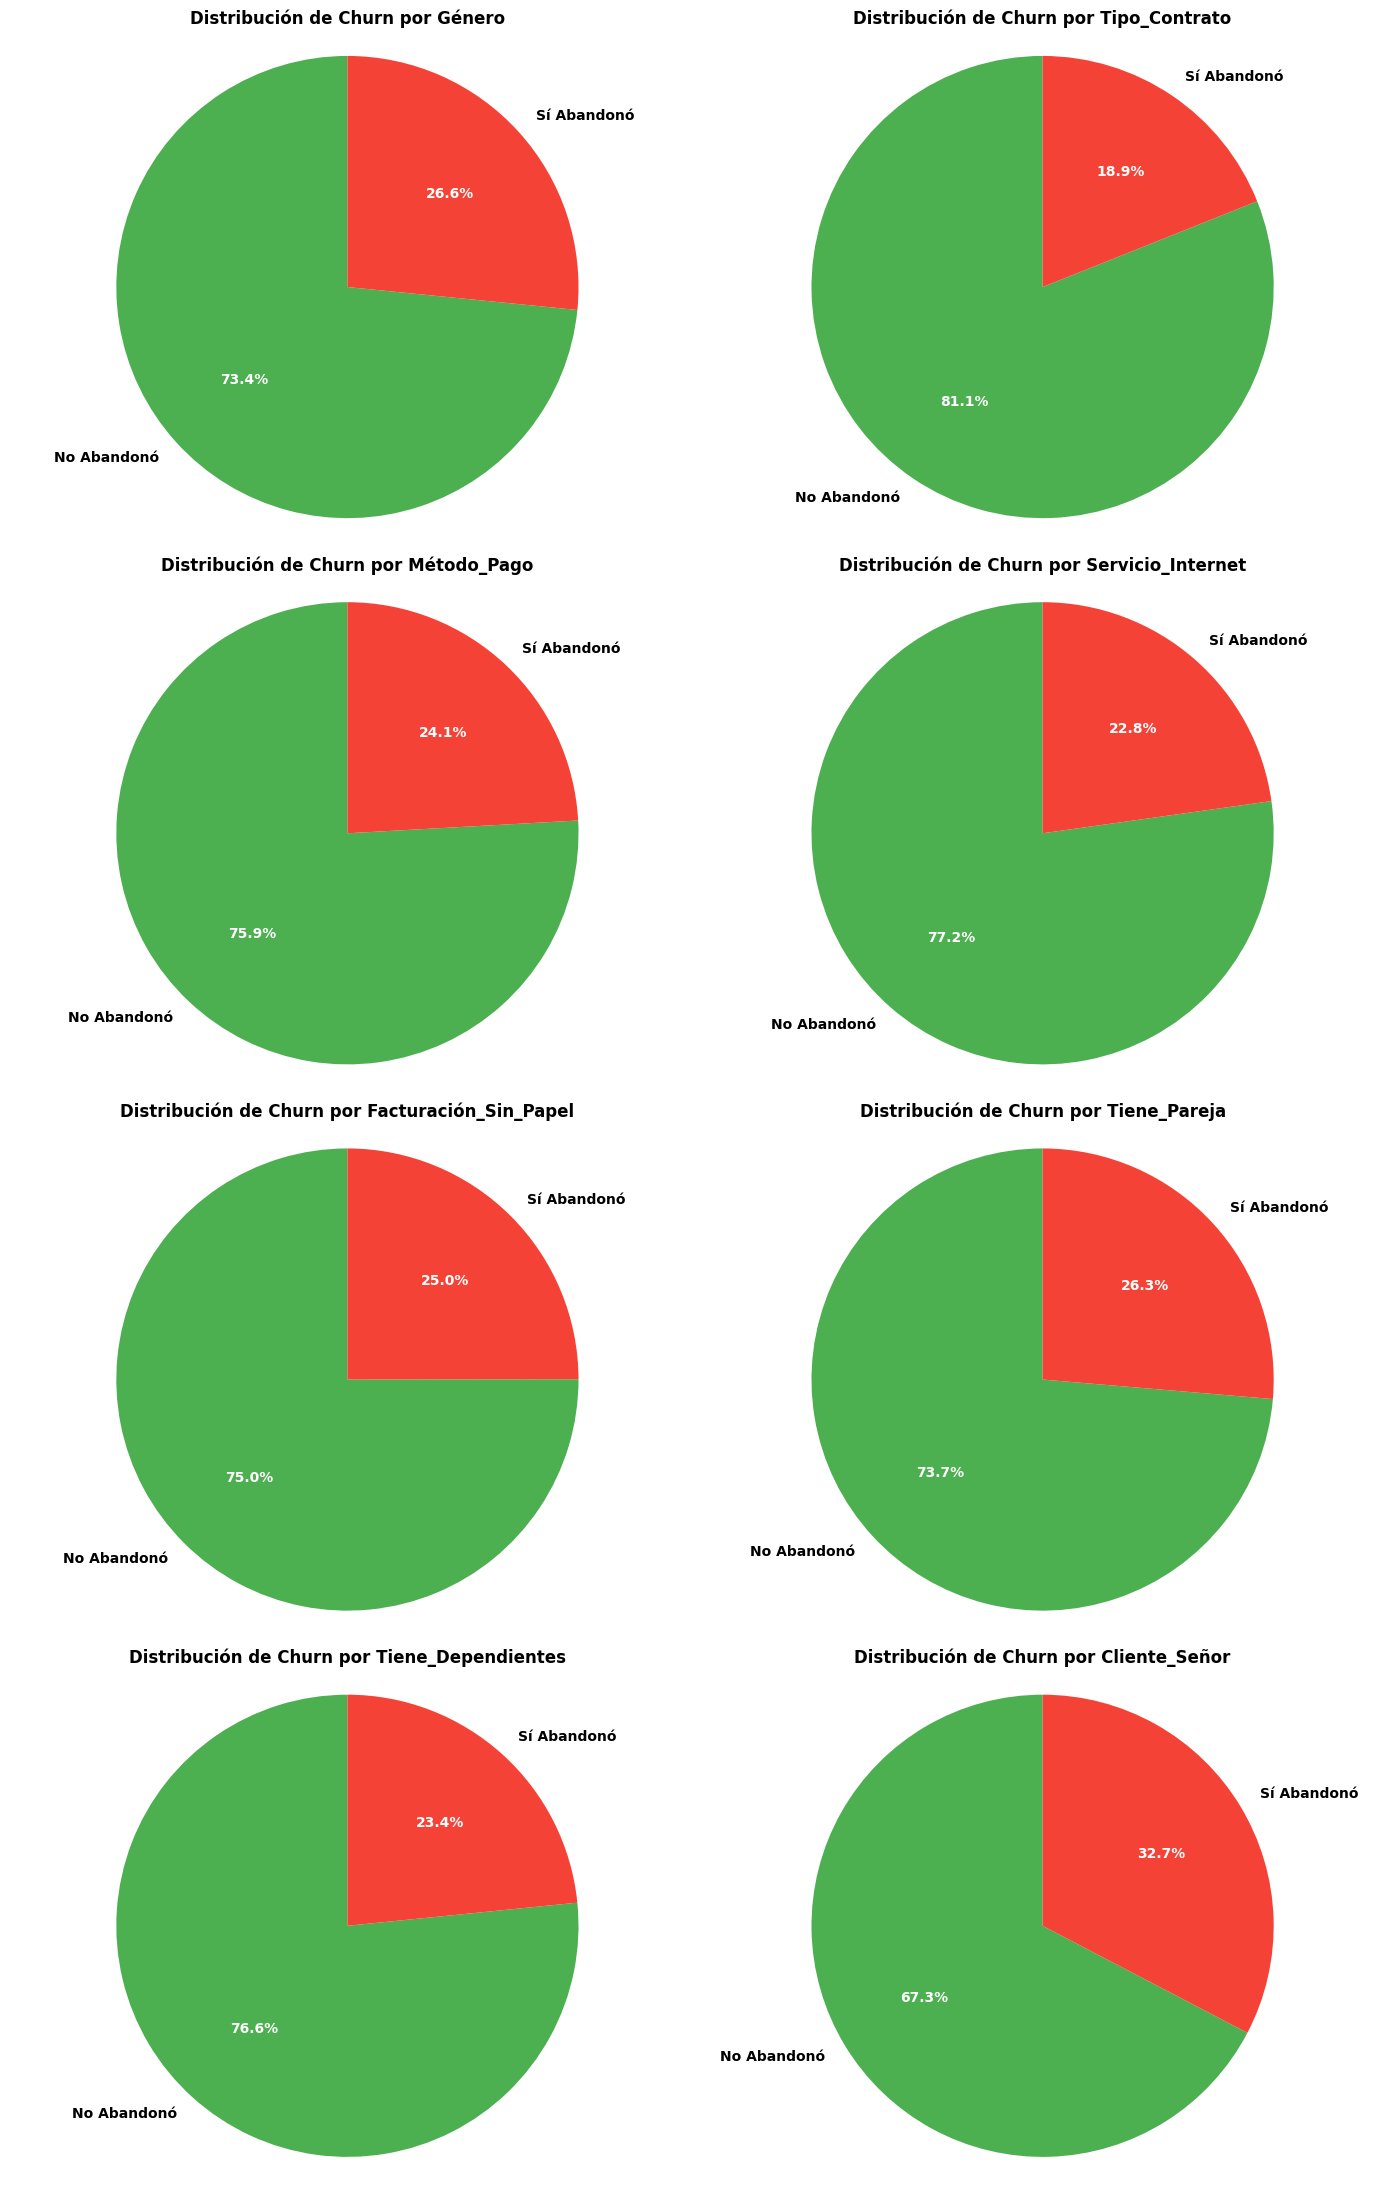

In [ ]:
grafica_evasion_categorica().show()

**📋 Observaciones**
### Mayor Riesgo de Abandono
- **Contrato Mensual**: 42.7% churn
- **Fibra Óptica**: 41.9% churn  
- **Cliente Senior**: 41.7% churn
- **Cheque Electrónico**: 45.3% churn

### Conclusión Principal

El perfil de mayor riesgo combina: **contrato mensual + fibra óptica + pago electrónico + sin vínculos familiares**. Los contratos a largo plazo reducen drásticamente el churn.

##3.4 Conteo de evasión por variables numéricas

In [ ]:
def histogram():
  # Calculate total charges for churned and non-churned customers
  total_charges_by_churn = df_normalizado.groupby('Abandonó_Servicio')['Cargo_Total'].sum()

  # Map churn values to meaningful labels
  labels = ['No Abandonó', 'Sí Abandonó']
  colors = ['#4CAF50', '#F44336'] # Green for No Churn, Red for Churn

  # Create the pie chart
  fig, ax = plt.subplots(figsize=(8, 8))
  ax.pie(total_charges_by_churn,
         labels=labels,
         autopct='%1.1f%%',
         colors=colors,
         startangle=90,
         pctdistance=0.85,
         wedgeprops=dict(width=0.4)) # Create a donut chart effect

  # Draw white circle in the middle for donut chart
  centre_circle = plt.Circle((0,0),0.70,fc='white')
  fig.gca().add_artist(centre_circle)

  ax.set_title('Proporción del Cargo Total por Abandono de Servicio',
               fontsize=16, fontweight='bold')
  ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

  plt.savefig("grafico_cargostotal_pastel.jpg", transparent=True)
  plt.show()
  return plt

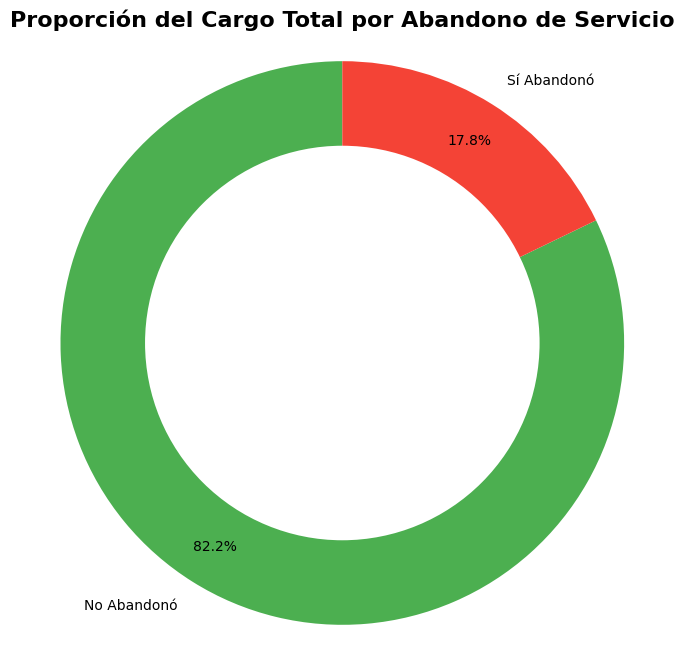

In [ ]:
histogram().show()

In [ ]:
def abandonaron():
  df_normalizado["antiguedad_bin"] = pd.cut(df_normalizado['Antigüedad'], bins=[0, 18, 36, 54, 72], right=False)
  churn_por_antig = (df_normalizado.groupby("antiguedad_bin", observed=False)["Abandonó_Servicio"].value_counts(normalize=True).unstack(fill_value=0) * 100)
  # Graficamos la columna [1] con nuevo estilo
  ax = churn_por_antig[1].plot(kind="line", marker="D", figsize=(12, 6), color="#6A0572", linestyle='--', linewidth=2, markersize=8) # Color morado, marcador diamante
  # Ajustes de etiquetas y leyenda con nuevo estilo de fuente
  ax.set_title("Tasa de Abandono por Antigüedad del Cliente", fontsize=16, fontweight="bold", color="#333333")
  ax.set_xlabel("Rango de Antigüedad (Meses)", fontsize=13, fontweight="bold", color="#555555")
  ax.set_ylabel("Tasa de Abandono (%)", fontsize=13, fontweight="bold", color="#555555")
  ax.legend(["Tasa de Abandono"], loc="upper left", fontsize=10, frameon=False) # Leyenda actualizada

  plt.grid(linestyle=':', alpha=0.7, color='gray') # Cuadrícula más suave
  plt.xticks(fontsize=10, color="#666666") # Estilo de texto en x
  plt.yticks(fontsize=10, color="#666666") # Estilo de texto en y
  plt.tight_layout() # Ajustar el diseño para evitar solapamientos
  plt.savefig("grafico_abandono_nuevo_estilo.jpg", transparent=True)
  plt.show()
  return plt

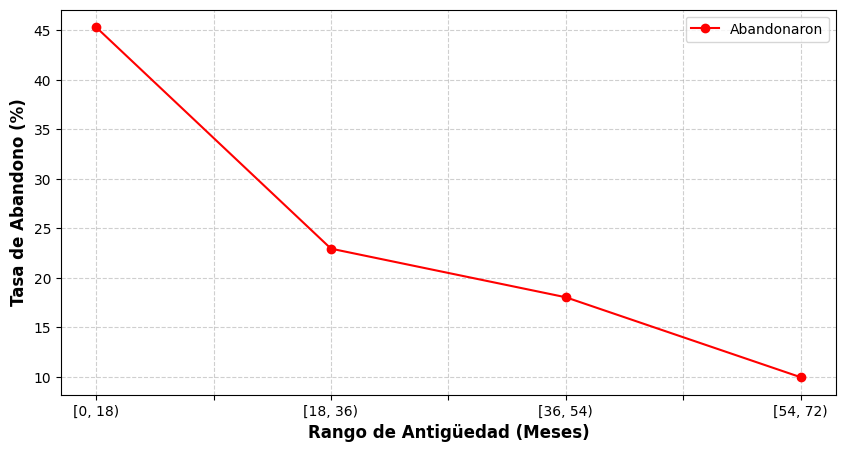

In [ ]:
abandonaron().show()

##3.5 Correlación

In [ ]:
matriz_corr = df_normalizado.corr(numeric_only=True)
print(matriz_corr)

                        Abandonó_Servicio  Cliente_Señor  Tiene_Pareja  \
Abandonó_Servicio                1.000000       0.150541     -0.149982   
Cliente_Señor                    0.150541       1.000000      0.016957   
Tiene_Pareja                    -0.149982       0.016957      1.000000   
Tiene_Dependientes              -0.163128      -0.210550      0.452269   
Antigüedad                      -0.354049       0.015683      0.381912   
Servicio_Telefónico              0.011691       0.008392      0.018397   
Múltiples_Líneas                 0.040033       0.142996      0.142561   
Seguridad_Online                -0.171270      -0.038576      0.143346   
Respaldo_Online                 -0.082307       0.066663      0.141849   
Protección_Dispositivo          -0.066193       0.059514      0.153556   
Soporte_Técnico                 -0.164716      -0.060577      0.120206   
TV_Streaming                     0.063254       0.105445      0.124483   
Películas_Streaming              0.060

#Informe final

> **Objetivo:** Identificar los factores que influyen en el abandono de clientes de TelecomX y proponer recomendaciones estratégicas para reducirlo.

---

## 1. Descripción del Dataset

| Característica | Detalle |
|---|---|
| Registros originales | 7.267 |
| Registros tras limpieza | 7.032 |
| Variables analizadas | 22 |
| Variable objetivo | `Abandonó_Servicio` |

El dataset fue extraído en formato JSON anidado y normalizado en columnas planas. Se eliminaron 235 registros por valores vacíos en `Churn` y valores no numéricos en `Charges.Total`. No se encontraron duplicados.

---

## 2. Proceso ETL

### Extracción
- Fuente: repositorio GitHub (Alura Cursos)
- Formato original: JSON con columnas anidadas (`customer`, `phone`, `internet`, `account`)

### Transformación
- Desanidado de columnas JSON con `pd.json_normalize`
- Eliminación de registros con `Churn` vacío y `Charges.Total` no numérico
- Conversión de variables binarias (`Yes`/`No`) a enteros (1/0)
- Traducción de columnas y valores al español
- Creación de variable derivada `Cargo_Diario` = `Cargo_Mensual / 30`
- Reset de índice para integridad del DataFrame

---

## 3. Análisis Descriptivo

### Tasa de Abandono General

```
Clientes que permanecieron:  73.42%
Clientes que abandonaron:    26.58%  
```
> **1 de cada 4 clientes abandona el servicio.** Esta tasa supera el umbral crítico del 20%, requiriendo atención inmediata.

### Estadísticas Clave de Variables Numéricas

| Variable | Media | Rango |
|---|---|---|
| Antigüedad | 32 meses | 1 — 72 meses |
| Cargo Mensual | $64.80 | $18.25 — $118.75 |
| Cargo Total | $2,283 | $18.80 — $8,684 |
| Cargo Diario | $2.16 | $0.61 — $3.96 |

### Adopción de Servicios

| Servicio | Adopción |
|---|---|
| Servicio Telefónico | 90.33% |
| Facturación Sin Papel | 59.27% |
| Streaming (TV/Películas) | ~38–39% |
| Seguridad / Soporte / Protección | 28–34% |
| Clientes Senior | 16.24% |

---

## 4. Análisis por Variables Categóricas

### Factores de Alto Riesgo (Churn > 40%)

| Factor | Tasa de Churn |
|---|---|
| Pago con Cheque Electrónico | 45.3% |
| Contrato Mensual | 42.7% |
| Servicio de Fibra Óptica | 41.9% |
| Cliente Senior | 41.7% |

### Factores de Riesgo Moderado (Churn 30–35%)

| Factor | Tasa de Churn |
|---|---|
| Facturación Sin Papel | 33.6% |
| Sin Pareja | 33.0% |
| Sin Dependientes | 31.3% |

### Factores de Bajo Riesgo (Churn < 20%)

| Factor | Tasa de Churn |
|---|---|
| Contrato Bienal | 2.8% |
| Sin Servicio de Internet | 7.4% |
| Contrato Anual | 11.3% |
| Con Dependientes | 15.5% |
| Servicio DSL | 18.9% |

> **El género no representa un factor diferencial** (Femenino 27.0% vs Masculino 26.2%).

---

## 5. Análisis por Variables Numéricas

### Antigüedad vs Churn
- Los clientes **nuevos (0–18 meses)** presentan la **mayor tasa de abandono**
- A medida que aumenta la antigüedad, el churn disminuye significativamente
- Los clientes con más de 54 meses tienen tasas de abandono mínimas

### Cargos Totales vs Churn
- Los clientes que abandonan concentran sus cargos totales en valores **bajos**, indicando que se van **antes de acumular historial de pago**
- Los clientes que permanecen muestran una distribución más amplia de cargos totales

---

## 6. Análisis de Correlaciones con Churn

### Correlaciones más relevantes con `Abandonó_Servicio`

| Variable | Correlación | Dirección |
|---|---|---|
| Antigüedad | -0.354 | 🔽 A mayor antigüedad, menor churn |
| Cargo Total | -0.199 | 🔽 A mayor gasto acumulado, menor churn |
| Facturación Sin Papel | +0.191 | 🔼 Asociado a mayor churn |
| Cargo Mensual | +0.193 | 🔼 Mayor cargo mensual, mayor riesgo |
| Tiene Dependientes | -0.163 | 🔽 Con dependientes, menor churn |
| Seguridad Online | -0.171 | 🔽 Con seguridad, menor churn |
| Soporte Técnico | -0.165 | 🔽 Con soporte, menor churn |
| Cliente Senior | +0.151 | 🔼 Clientes senior, mayor riesgo |

> **La antigüedad es el predictor más fuerte del churn** (r = -0.354). Retener al cliente en los primeros 18 meses es crítico.

---

## 7. Conclusiones y Recomendaciones

### Perfil de Mayor Riesgo
> Cliente con **contrato mensual + fibra óptica + pago por cheque electrónico + sin vínculos familiares + antigüedad menor a 18 meses**

### Perfil de Menor Riesgo
> Cliente con **contrato bienal o anual + con pareja o dependientes + DSL + alta antigüedad**

### Recomendaciones Estratégicas

1. **Incentivar contratos largos:** Ofrecer descuentos o beneficios para migrar de mensual a anual/bienal, dado que el churn cae de 42.7% a 11.3% y 2.8% respectivamente.

2. **Atención especial en los primeros 18 meses:** Implementar programas de onboarding y seguimiento activo para reducir la fuga temprana.

3. **Revisar la oferta de Fibra Óptica:** Con un 41.9% de churn, es necesario evaluar si los precios, la calidad o el soporte técnico están generando insatisfacción.

4. **Fomentar servicios de valor agregado:** Clientes con Seguridad Online y Soporte Técnico presentan menor churn; promover su adopción puede mejorar la retención.

5. **Estrategia diferenciada para clientes senior:** Representan el 16.24% de la base pero tienen un churn del 41.7%; se recomienda atención personalizada y planes adaptados.

6. **Revisión del método de pago:** Migrar clientes del cheque electrónico (45.3% churn) hacia métodos automáticos puede reducir la fricción en el pago y mejorar la retención.